In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

rng = np.random.default_rng()

# 1. Метод 12

In [2]:
def random_normal_method_of_12(size: int = 1):
    n = 12
    uniform = rng.uniform(0., 1., size=(n, size)) - 0.5
    return np.sum(uniform, axis=0) * np.sqrt(12) / np.sqrt(n)

Смоделируем методом 12 нормально распределенную выборку $X \sim \mathcal{N}(0, 1)$ размера $N = 10^7$, и построим гистограмму плотности распределения.

In [3]:
sample_size = 10 ** 7
sample = random_normal_method_of_12(size=sample_size)

num_bins = 32
sample_hist, bin_edges = np.histogram(sample, bins=num_bins, density=True)

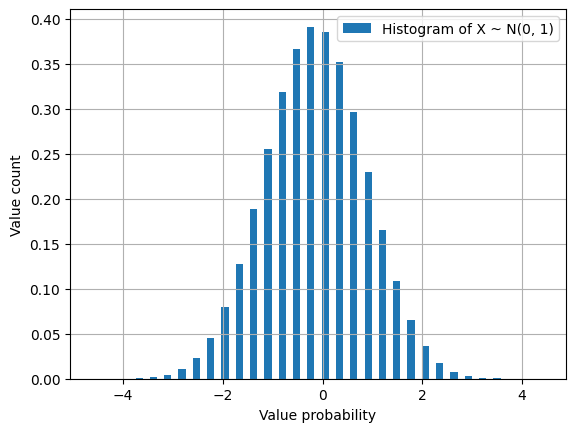

In [4]:
plt.bar(bin_edges[:-1], sample_hist, width=np.diff(bin_edges) / 2, label='Histogram of X ~ N(0, 1)')
plt.xlabel('Value probability')
plt.ylabel('Value count')
plt.legend()
plt.grid()

In [5]:
def distribution_error(
    p: np.ndarray,
    p_true: np.ndarray
):
    return np.sum((p - p_true) ** 2)

In [6]:
sample_sizes = [10 ** n for n in range(2, 8)]
errors = []

progress_bar = tqdm(sample_sizes, desc=f"Compute distribution error for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = random_normal_method_of_12(size=sample_size)
    hist, _ = np.histogram(sample, bins=num_bins, density=True)

    sample_true = rng.normal(0, 1, size=sample_size)
    hist_true, _ = np.histogram(sample_true, bins=num_bins, density=True)

    error = distribution_error(p=hist, p_true=hist_true)
    errors.append(error)

Compute distribution error for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000]: 100%|██████████| 6/6 [00:02<00:00,  2.77it/s]


Построим график зависимости погрешности `distribution_error` от размера выборки $N$.

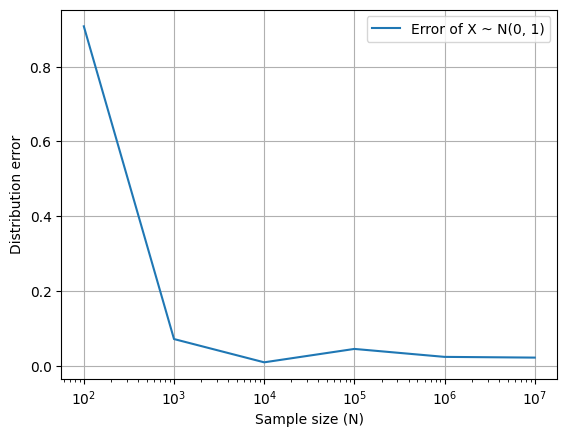

In [8]:
plt.plot(sample_sizes, errors, label='Error of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Distribution error')
plt.xscale('log')
plt.legend()
plt.grid()

Вычислим оценки мат ожидания и дисперсии, и сравним их с точными значениями для распределения $\mathcal{N}(0, 1)$.

In [9]:
sample_sizes = [10 ** n for n in range(2, 8)]
sample_means = []
sample_vars = []
mean_exact, var_exact = 0, 1

progress_bar = tqdm(sample_sizes, desc=f"Compute mean and var for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = random_normal_method_of_12(size=sample_size)
    
    sample_mean = np.mean(sample)
    sample_var = np.var(sample)

    sample_means.append(sample_mean)
    sample_vars.append(sample_var)

Compute mean and var for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000]: 100%|██████████| 6/6 [00:01<00:00,  3.16it/s]


Вычислим оценки мат ожидания для различных размеров выборки $N$, и сравным с точным значением `mean_exact` на графике.

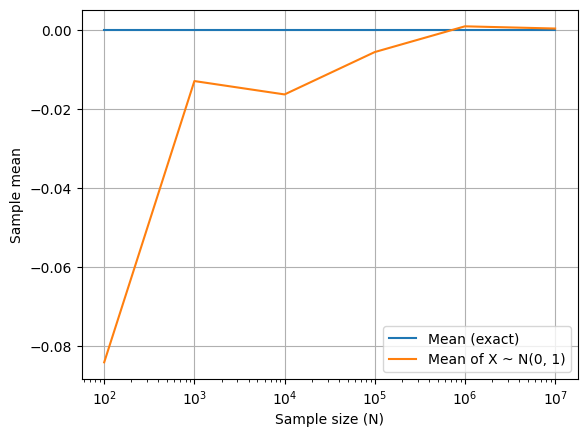

In [10]:
plt.plot(sample_sizes, [mean_exact] * len(sample_sizes), label='Mean (exact)')
plt.plot(sample_sizes, sample_means, label='Mean of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample mean')
plt.xscale('log')
plt.legend()
plt.grid()

Вычислим оценки дисперсии для различных размеров выборки $N$, и сравным с точным значением `var_exact` на графике.

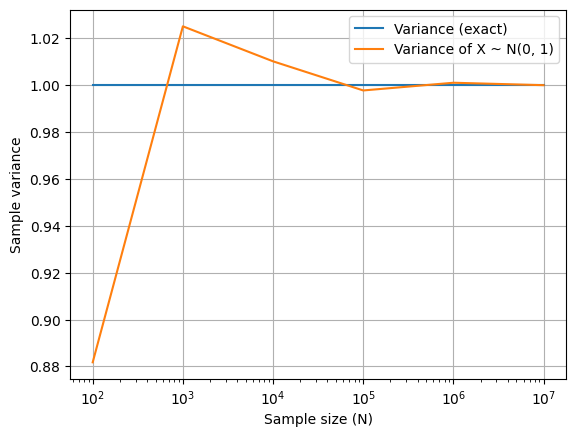

In [20]:
plt.plot(sample_sizes, [var_exact] * len(sample_sizes), label='Variance (exact)')
plt.plot(sample_sizes, sample_vars, label='Variance of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample variance')
plt.xscale('log')
plt.legend()
plt.grid()

**Итог**: метод 12 для генерации нормально распределенной выборки требует довольно много памяти в текущей реализации на Python, поэтому эмпирические параметры распределения были вычислены для выборок размеров $N \leq 10^7$. Даже на таких размерах выборок графики демонстрируют, что с увеличением размера выборки мат ожидание и дисперсия стремятся к точным значениям. Ошибка плотности по сравнению с истинным нормальным распределением стремится к 0.

# 2. Преобразование Бокса -- Мюллера

In [12]:
def random_normal_box_muller(size: int = 1):
    a, b = rng.uniform(0., 1., size=(2, size))
    xi_1 = np.sqrt(-2 * np.log(a)) * np.cos(2 * np.pi * b)
    # xi_2 = np.sqrt(-2 * np.log(a)) * np.sin(2 * np.pi * b)
    return xi_1

Смоделируем с помощью преобразования Бокса -- Мюллера нормально распределенную выборку $X \sim \mathcal{N}(0, 1)$ размера $N = 10^7$, и построим гистограмму плотности распределения.

In [26]:
sample_size = 10 ** 7
sample = random_normal_box_muller(size=sample_size)

num_bins = 32
sample_hist, bin_edges = np.histogram(sample, bins=num_bins, density=True)

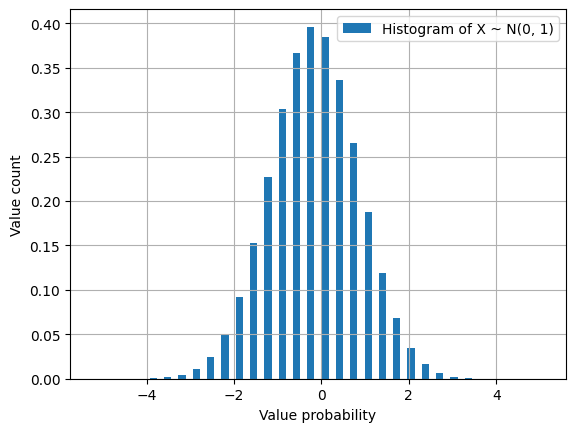

In [27]:
plt.bar(bin_edges[:-1], sample_hist, width=np.diff(bin_edges) / 2, label='Histogram of X ~ N(0, 1)')
plt.xlabel('Value probability')
plt.ylabel('Value count')
plt.legend()
plt.grid()

In [28]:
sample_sizes = [10 ** n for n in range(2, 8)]
errors = []

progress_bar = tqdm(sample_sizes, desc=f"Compute distribution error for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = random_normal_box_muller(size=sample_size)
    hist, _ = np.histogram(sample, bins=num_bins, density=True)

    sample_true = rng.normal(0, 1, size=sample_size)
    hist_true, _ = np.histogram(sample_true, bins=num_bins, density=True)

    error = distribution_error(p=hist, p_true=hist_true)
    errors.append(error)

Compute distribution error for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000]: 100%|██████████| 6/6 [00:01<00:00,  3.57it/s]


Построим график зависимости погрешности `distribution_error` от размера выборки $N$.

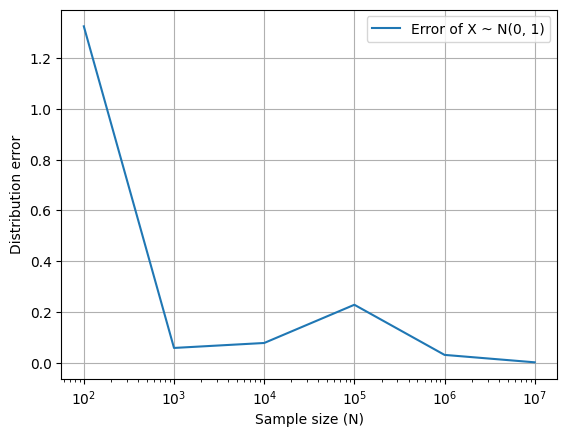

In [29]:
plt.plot(sample_sizes, errors, label='Error of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Distribution error')
plt.xscale('log')
plt.legend()
plt.grid()

Вычислим оценки мат ожидания и дисперсии, и сравним их с точными значениями для распределения $\mathcal{N}(0, 1)$.

In [30]:
sample_sizes = [10 ** n for n in range(2, 8)]
sample_means = []
sample_vars = []
mean_exact, var_exact = 0, 1

progress_bar = tqdm(sample_sizes, desc=f"Compute mean and var for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = random_normal_method_of_12(size=sample_size)
    
    sample_mean = np.mean(sample)
    sample_var = np.var(sample)

    sample_means.append(sample_mean)
    sample_vars.append(sample_var)

Compute mean and var for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000]: 100%|██████████| 6/6 [00:01<00:00,  3.05it/s]


Вычислим оценки мат ожидания для различных размеров выборки $N$, и сравным с точным значением `mean_exact` на графике.

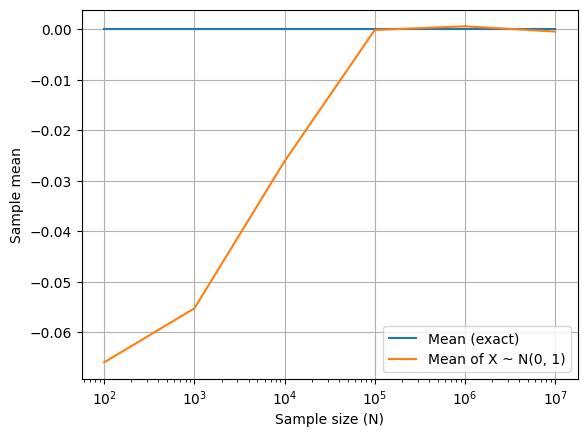

In [31]:
plt.plot(sample_sizes, [mean_exact] * len(sample_sizes), label='Mean (exact)')
plt.plot(sample_sizes, sample_means, label='Mean of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample mean')
plt.xscale('log')
plt.legend()
plt.grid()

Вычислим оценки дисперсии для различных размеров выборки $N$, и сравным с точным значением `var_exact` на графике.

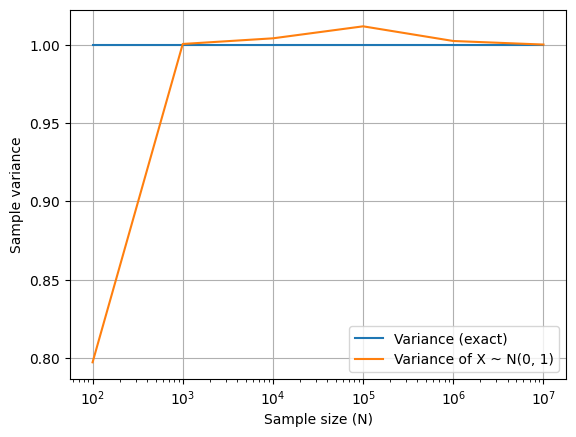

In [32]:
plt.plot(sample_sizes, [var_exact] * len(sample_sizes), label='Variance (exact)')
plt.plot(sample_sizes, sample_vars, label='Variance of X ~ N(0, 1)')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample variance')
plt.xscale('log')
plt.legend()
plt.grid()

**Итог**: преобразование Бокса -- Мюллера для генерации нормально распределенной выборки требует довольно много памяти в текущей реализации на Python, поэтому эмпирические параметры распределения были вычислены для выборок размеров $N \leq 10^7$. Даже на таких размерах выборок графики демонстрируют, что с увеличением размера выборки мат ожидание и дисперсия стремятся к точным значениям. Ошибка плотности по сравнению с истинным нормальным распределением стремится к 0.